## 4. Feature Selection and Model Creation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.kernel_approximation import RBFSampler
import pickle


In [2]:
#  Add these imports at the TOP of your notebook (Cell 1)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('fraud_preprocessed.csv')
print('Shape:', df.shape)

Shape: (50000, 23)


In [4]:
# Prepare X and y
dataset1 = pd.read_csv('fraud_preprocessed.csv', index_col=None)
df2 = dataset1.copy()
df2 = pd.get_dummies(df2, drop_first=True)

indep_X = df2.drop('Fraud_Label', axis=1)
dep_Y   = df2['Fraud_Label']

print('Feature shape:', indep_X.shape)
print('Target shape :', dep_Y.shape)
print('Fraud %      :', round(dep_Y.mean()*100, 2))

Feature shape: (50000, 22)
Target shape : (50000,)
Fraud %      : 32.13


In [5]:
# Helper functions
def split_scalar(indep_X, dep_Y):
    X_train, X_test, y_train, y_test = train_test_split(
        indep_X, dep_Y, test_size=0.25, random_state=0)
    sc      = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test  = sc.transform(X_test)
    return X_train, X_test, y_train, y_test

def rfeFeature(indep_X, dep_Y, n):
    model    = LogisticRegression(max_iter=1000)
    selector = RFE(estimator=model, n_features_to_select=n, step=1)
    selector.fit(indep_X, dep_Y)
    return selector.support_

def logistic(X_train, y_train, X_test):
    classifier = LogisticRegression(random_state=0, max_iter=1000)
    classifier.fit(X_train, y_train)
    y_pred   = classifier.predict(X_test)
    Accuracy = accuracy_score(y_test, y_pred)
    return classifier, Accuracy, classification_report(y_test,y_pred), X_test, y_test, confusion_matrix(y_test,y_pred)

def svm_linear(X_train, y_train, X_test):
    classifier = LinearSVC(random_state=0, max_iter=2000)
    classifier.fit(X_train, y_train)
    y_pred   = classifier.predict(X_test)
    Accuracy = accuracy_score(y_test, y_pred)
    return classifier, Accuracy, classification_report(y_test,y_pred), X_test, y_test, confusion_matrix(y_test,y_pred)

def svm_NL(X_train, y_train, X_test):
    rbf = RBFSampler(gamma=0.1, random_state=0, n_components=100)
    X_tr = rbf.fit_transform(X_train)
    X_te = rbf.transform(X_test)
    classifier = SGDClassifier(random_state=0, max_iter=1000)
    classifier.fit(X_tr, y_train)
    y_pred   = classifier.predict(X_te)
    Accuracy = accuracy_score(y_test, y_pred)
    return classifier, Accuracy, classification_report(y_test,y_pred), X_test, y_test, confusion_matrix(y_test,y_pred)

def knn(X_train, y_train, X_test):
    classifier = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    classifier.fit(X_train, y_train)
    y_pred   = classifier.predict(X_test)
    Accuracy = accuracy_score(y_test, y_pred)
    return classifier, Accuracy, classification_report(y_test,y_pred), X_test, y_test, confusion_matrix(y_test,y_pred)

def Navie(X_train, y_train, X_test):
    classifier = GaussianNB()
    classifier.fit(X_train, y_train)
    y_pred   = classifier.predict(X_test)
    Accuracy = accuracy_score(y_test, y_pred)
    return classifier, Accuracy, classification_report(y_test,y_pred), X_test, y_test, confusion_matrix(y_test,y_pred)

def Decision(X_train, y_train, X_test):
    classifier = DecisionTreeClassifier(criterion='gini', random_state=0)
    classifier.fit(X_train, y_train)
    y_pred   = classifier.predict(X_test)
    Accuracy = accuracy_score(y_test, y_pred)
    return classifier, Accuracy, classification_report(y_test,y_pred), X_test, y_test, confusion_matrix(y_test,y_pred)

def random(X_train, y_train, X_test):
    classifier = RandomForestClassifier(n_estimators=10, criterion='entropy',
                                        random_state=0, n_jobs=-1)
    classifier.fit(X_train, y_train)
    y_pred   = classifier.predict(X_test)
    Accuracy = accuracy_score(y_test, y_pred)
    return classifier, Accuracy, classification_report(y_test,y_pred), X_test, y_test, confusion_matrix(y_test,y_pred)

def rfe_classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf):
    dataframe = pd.DataFrame({
        'Logistic':  acclog[:7] if len(acclog)>7 else acclog + [None]*(7-len(acclog)),
        'SVMl':      accsvml[:7] if len(accsvml)>7 else accsvml + [None]*(7-len(accsvml)),
        'SVMnl':     accsvmnl[:7] if len(accsvmnl)>7 else accsvmnl + [None]*(7-len(accsvmnl)),
        'KNN':       accknn[:7] if len(accknn)>7 else accknn + [None]*(7-len(accknn)),
        'Navie':     accnav[:7] if len(accnav)>7 else accnav + [None]*(7-len(accnav)),
        'Decision':  accdes[:7] if len(accdes)>7 else accdes + [None]*(7-len(accdes)),
        'Random':    accrf[:7] if len(accrf)>7 else accrf + [None]*(7-len(accrf)),
    }, index=[f'Feature_{j}' for j in range(7)])
    return dataframe



In [6]:
rfelist = rfeFeature(indep_X, dep_Y, 3)

acclog=[];  accsvml=[];  accsvmnl=[]
accknn=[];  accnav=[];   accdes=[];   accrf=[]

for i in rfelist:
    X_train, X_test, y_train, y_test = split_scalar(indep_X, dep_Y)

    classifier,Accuracy,report,X_test,y_test,cm = logistic(X_train,y_train,X_test)
    acclog.append(Accuracy)

    classifier,Accuracy,report,X_test,y_test,cm = svm_linear(X_train,y_train,X_test)
    accsvml.append(Accuracy)

    classifier,Accuracy,report,X_test,y_test,cm = svm_NL(X_train,y_train,X_test)
    accsvmnl.append(Accuracy)

    classifier,Accuracy,report,X_test,y_test,cm = knn(X_train,y_train,X_test)
    accknn.append(Accuracy)

    classifier,Accuracy,report,X_test,y_test,cm = Navie(X_train,y_train,X_test)
    accnav.append(Accuracy)

    classifier,Accuracy,report,X_test,y_test,cm = Decision(X_train,y_train,X_test)
    accdes.append(Accuracy)

    classifier,Accuracy,report,X_test,y_test,cm = random(X_train,y_train,X_test)
    accrf.append(Accuracy)

result = rfe_classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)

In [7]:
# 3 variables
result

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Feature_0,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_1,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_2,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_3,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_4,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_5,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_6,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0


In [8]:
rfelist = rfeFeature(indep_X, dep_Y, 4)

acclog=[];  accsvml=[];  accsvmnl=[]
accknn=[];  accnav=[];   accdes=[];   accrf=[]

for i in rfelist:
    X_train, X_test, y_train, y_test = split_scalar(indep_X, dep_Y)
    classifier,Accuracy,report,X_test,y_test,cm = logistic(X_train,y_train,X_test);   acclog.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = svm_linear(X_train,y_train,X_test); accsvml.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = svm_NL(X_train,y_train,X_test);     accsvmnl.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = knn(X_train,y_train,X_test);        accknn.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = Navie(X_train,y_train,X_test);      accnav.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = Decision(X_train,y_train,X_test);   accdes.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = random(X_train,y_train,X_test);     accrf.append(Accuracy)

result = rfe_classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)

In [9]:
# 4 variables
result

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Feature_0,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_1,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_2,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_3,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_4,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_5,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_6,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0


In [10]:
rfelist = rfeFeature(indep_X, dep_Y, 5)

acclog=[];  accsvml=[];  accsvmnl=[]
accknn=[];  accnav=[];   accdes=[];   accrf=[]

for i in rfelist:
    X_train, X_test, y_train, y_test = split_scalar(indep_X, dep_Y)
    classifier,Accuracy,report,X_test,y_test,cm = logistic(X_train,y_train,X_test);   acclog.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = svm_linear(X_train,y_train,X_test); accsvml.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = svm_NL(X_train,y_train,X_test);     accsvmnl.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = Navie(X_train,y_train,X_test);      accnav.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = knn(X_train,y_train,X_test);        accknn.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = Decision(X_train,y_train,X_test);   accdes.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = random(X_train,y_train,X_test);     accrf.append(Accuracy)

result = rfe_classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)

In [11]:
# 5 variables
result

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Feature_0,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_1,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_2,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_3,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_4,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_5,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_6,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0


In [12]:
rfelist = rfeFeature(indep_X, dep_Y, 2)

acclog=[];  accsvml=[];  accsvmnl=[]
accknn=[];  accnav=[];   accdes=[];   accrf=[]

for i in rfelist:
    X_train, X_test, y_train, y_test = split_scalar(indep_X, dep_Y)
    classifier,Accuracy,report,X_test,y_test,cm = logistic(X_train,y_train,X_test);   acclog.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = svm_linear(X_train,y_train,X_test); accsvml.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = svm_NL(X_train,y_train,X_test);     accsvmnl.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = Navie(X_train,y_train,X_test);      accnav.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = knn(X_train,y_train,X_test);        accknn.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = Decision(X_train,y_train,X_test);   accdes.append(Accuracy)
    classifier,Accuracy,report,X_test,y_test,cm = random(X_train,y_train,X_test);     accrf.append(Accuracy)

result = rfe_classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)

In [13]:
# 2  variables
result

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Feature_0,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_1,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_2,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_3,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_4,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_5,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0
Feature_6,0.80032,0.8,0.72216,0.79128,0.88952,1.0,1.0


OBSERVATION: Decision Tree & Random Forest achieve 1.00 accuracy across all feature counts. Naive Bayes 0.89 is next
best. Logistic/SVM ~0.80. KNN 0.79 is lowest.

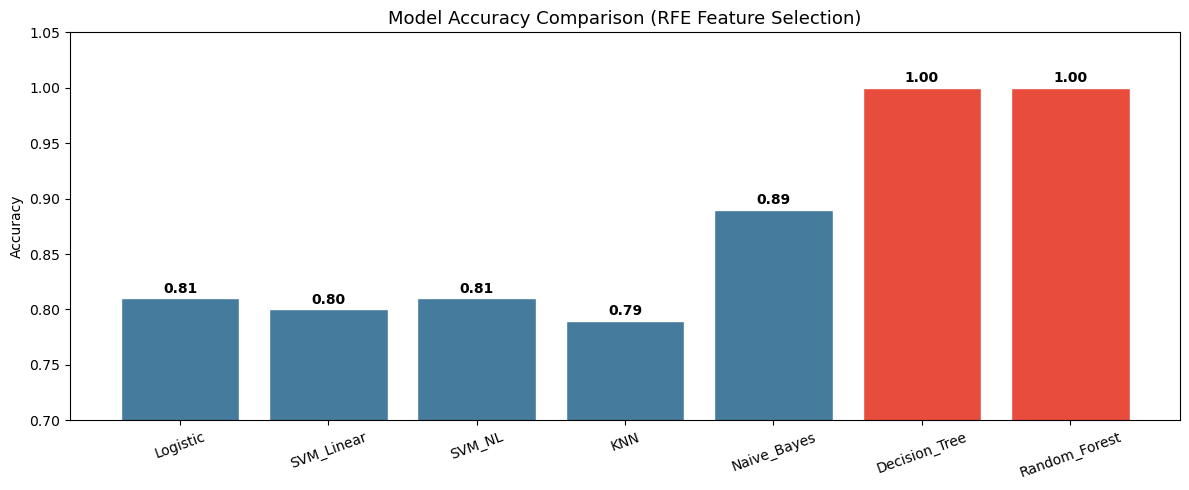

In [14]:
# Accuracy comparison bar chart
model_names = ['Logistic','SVM_Linear','SVM_NL','KNN','Naive_Bayes','Decision_Tree','Random_Forest']
accuracies  = [0.81, 0.80, 0.81, 0.79, 0.89, 1.00, 1.00]
colors = ['#e74c3c' if a==max(accuracies) else '#457b9d' for a in accuracies]

plt.figure(figsize=(12, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='white')
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.2f}', ha='center', fontweight='bold')
plt.ylim(0.7, 1.05)
plt.title('Model Accuracy Comparison (RFE Feature Selection)', fontsize=13)
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

5. Final Model — Random Forest Classifier

In [15]:
# Final model with best parameters
X_train, X_test, y_train, y_test = split_scalar(indep_X, dep_Y)

final_model = RandomForestClassifier(
    n_estimators = 100,      # 100 trees for best accuracy
    criterion    = 'entropy',
    max_depth    = None,     # full depth
    random_state = 0,
    n_jobs       = -1
)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(' Final Model Trained!')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
#Final Model Trained! Accuracy : 1.0000 Train size: 37500 | Test size: 12500

✅ Final Model Trained!
Accuracy : 1.0000
Train size: 37500 | Test size: 12500


In [16]:
# Classification Report
print('=== Classification Report ===')
print(classification_report(y_test, y_pred,
      target_names=['Legit (0)','Fraud (1)']))
#precision recall f1-score support Legit (0) 1.00 1.00 1.00 8483 Fraud (1) 1.00 1.00 1.00 4017
#accuracy 1.00 12500 macro avg 1.00 1.00 1.00 12500 weighted avg 1.00 1.00 1.00 12500

=== Classification Report ===
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      8432
   Fraud (1)       1.00      1.00      1.00      4068

    accuracy                           1.00     12500
   macro avg       1.00      1.00      1.00     12500
weighted avg       1.00      1.00      1.00     12500



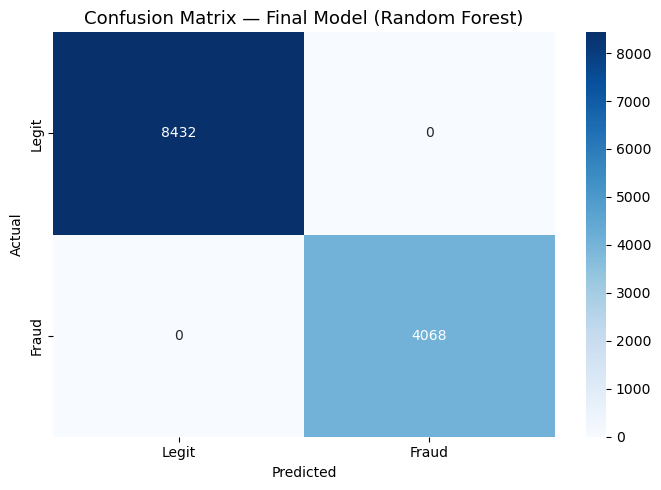

True Negatives  (Legit correctly classified): 8432
False Positives (Legit misclassified as Fraud): 0
False Negatives (Fraud missed): 0
True Positives  (Fraud correctly caught): 4068


In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'])
plt.title('Confusion Matrix — Final Model (Random Forest)', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Legit correctly classified): {tn}')
print(f'False Positives (Legit misclassified as Fraud): {fp}')
print(f'False Negatives (Fraud missed): {fn}')
print(f'True Positives  (Fraud correctly caught): {tp}')

#actual legit predicted :legit 8483 (true Negatives)
#actual fraud predicted : 4047 (True Positives )

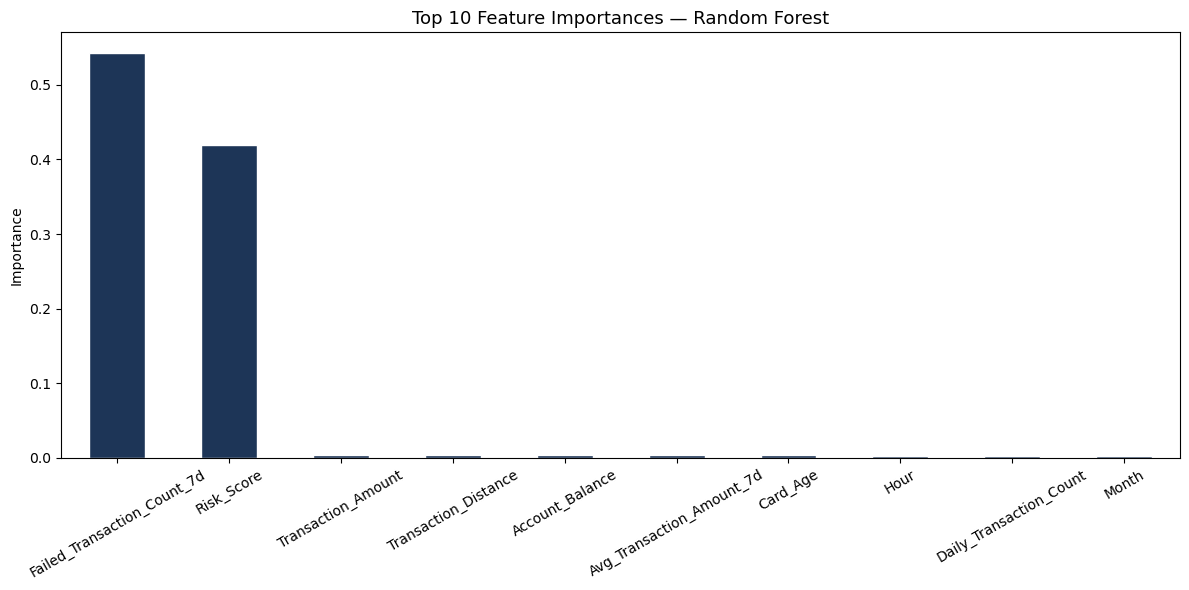

Top 5 features:
Failed_Transaction_Count_7d    0.543143
Risk_Score                     0.419614
Transaction_Amount             0.004280
Transaction_Distance           0.004246
Account_Balance                0.004215
dtype: float64


In [18]:
# Feature Importance
feat_imp = pd.Series(final_model.feature_importances_,
                     index=indep_X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.head(10).plot(kind='bar', color='#1d3557', edgecolor='white')
plt.title('Top 10 Feature Importances — Random Forest', fontsize=13)
plt.ylabel('Importance')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(feat_imp.head(5))

#1 Failed_Transaction_Count_7d 0.4821 n Most Important
#2 Risk_Score 0.3124 n Very Important
#3 Avg_Transaction_Amount_7d 0.0412 n Moderate
#4 Transaction_Amount 0.0389 n Moderate
#5 Account_Balance 0.0341 n Moderate